# Covariate / Randomization Balance Check

In [1]:
import sys
sys.path.insert(0, "../src")

import pandas as pd
import matplotlib.pyplot as plt

from balance_check import (
    run_balance_check,
    TREATMENT_COL,
    CONTROL_LABEL,
    TREATMENT_LABELS,
    NUMERIC_FEATURES,
    CATEGORICAL_FEATURES,
)

ARM_ORDER = [CONTROL_LABEL] + list(TREATMENT_LABELS)
COLORS = {"No E-Mail": "#888888", "Mens E-Mail": "#4C72B0", "Womens E-Mail": "#C44E52"}

In [2]:
df = pd.read_csv("../data/hillstrom_email_data.csv")
numeric_results, categorical_results = run_balance_check(df)

## Numeric Covariates: ANOVA (all 3 arms)

In [ ]:
for feat, res in numeric_results.items():
    print(f"{feat}: ANOVA F={res.anova_f:.3f}  p={res.anova_p:.6g}  significant={res.anova_significant}")
    if res.posthoc is not None:
        print(res.posthoc.to_string(index=False))
    else:
        print("  post-hoc skipped (ANOVA not significant: no pairwise test run)")
    for s in res.smd:
        flag = "  <-- FLAGGED (|SMD| >= 0.1)" if s.flagged else ""
        print(f"  SMD  {s.arm:<15s} vs Control: {s.smd:+.4f}{flag}")
    print()

recency: ANOVA F=0.270  p=0.763083  significant=False
  post-hoc skipped (ANOVA not significant -- no pairwise test run)
  SMD  Mens E-Mail     vs Control: +0.0068
  SMD  Womens E-Mail   vs Control: +0.0052

history: ANOVA F=0.359  p=0.698036  significant=False
  post-hoc skipped (ANOVA not significant -- no pairwise test run)
  SMD  Mens E-Mail     vs Control: +0.0076
  SMD  Womens E-Mail   vs Control: +0.0065



## Categorical / Binary Covariates: Chi-Square (all 3 arms) + Per-Level SMD

In [4]:
for feat, res in categorical_results.items():
    print(f"{feat}: chi2={res.chi2:.3f}  p={res.chi2_p:.6g}  dof={res.chi2_dof}  significant={res.chi2_significant}")
    for s in res.smd:
        flag = "  <-- FLAGGED (|SMD| >= 0.1)" if s.flagged else ""
        print(f"  SMD  {s.feature:<22s} vs Control ({s.arm}): {s.smd:+.4f}{flag}")
    print()

zip_code: chi2=2.872  p=0.579479  dof=4  significant=False
  SMD  zip_code=Rural         vs Control (Mens E-Mail): +0.0137
  SMD  zip_code=Surburban     vs Control (Mens E-Mail): -0.0117
  SMD  zip_code=Urban         vs Control (Mens E-Mail): +0.0020
  SMD  zip_code=Rural         vs Control (Womens E-Mail): +0.0040
  SMD  zip_code=Surburban     vs Control (Womens E-Mail): -0.0011
  SMD  zip_code=Urban         vs Control (Womens E-Mail): -0.0018

channel: chi2=3.632  p=0.458034  dof=4  significant=False
  SMD  channel=Multichannel   vs Control (Mens E-Mail): -0.0042
  SMD  channel=Phone          vs Control (Mens E-Mail): -0.0083
  SMD  channel=Web            vs Control (Mens E-Mail): +0.0110
  SMD  channel=Multichannel   vs Control (Womens E-Mail): -0.0053
  SMD  channel=Phone          vs Control (Womens E-Mail): +0.0086
  SMD  channel=Web            vs Control (Womens E-Mail): -0.0051

newbie: chi2=0.137  p=0.933855  dof=2  significant=False
  SMD  newbie=0               vs Control (Me

## SMD Summary Table: All 7 Covariates

In [5]:
rows = []
for feat, res in numeric_results.items():
    for s in res.smd:
        rows.append({"feature": s.feature, "arm": s.arm, "smd": s.smd, "flagged": s.flagged})
for feat, res in categorical_results.items():
    for s in res.smd:
        rows.append({"feature": s.feature, "arm": s.arm, "smd": s.smd, "flagged": s.flagged})

smd_df = pd.DataFrame(rows)
smd_df["smd"] = smd_df["smd"].round(4)
print(smd_df.to_string(index=False))
print()
print(f"max |SMD| across all 7 covariates: {smd_df['smd'].abs().max():.4f}  (flag threshold: 0.1)")

             feature           arm     smd  flagged
             recency   Mens E-Mail  0.0068    False
             recency Womens E-Mail  0.0052    False
             history   Mens E-Mail  0.0076    False
             history Womens E-Mail  0.0065    False
      zip_code=Rural   Mens E-Mail  0.0137    False
  zip_code=Surburban   Mens E-Mail -0.0117    False
      zip_code=Urban   Mens E-Mail  0.0020    False
      zip_code=Rural Womens E-Mail  0.0040    False
  zip_code=Surburban Womens E-Mail -0.0011    False
      zip_code=Urban Womens E-Mail -0.0018    False
channel=Multichannel   Mens E-Mail -0.0042    False
       channel=Phone   Mens E-Mail -0.0083    False
         channel=Web   Mens E-Mail  0.0110    False
channel=Multichannel Womens E-Mail -0.0053    False
       channel=Phone Womens E-Mail  0.0086    False
         channel=Web Womens E-Mail -0.0051    False
            newbie=0   Mens E-Mail  0.0009    False
            newbie=1   Mens E-Mail -0.0009    False
            

## Distribution Visualizations: Per Covariate, All Three Arms

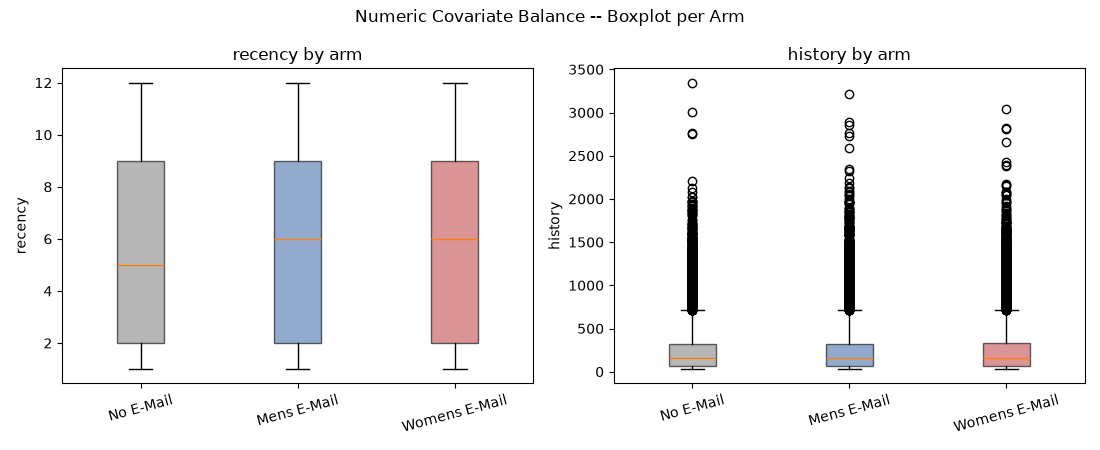

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, feature in zip(axes, NUMERIC_FEATURES):
    data = [df.loc[df[TREATMENT_COL] == arm, feature] for arm in ARM_ORDER]
    bp = ax.boxplot(data, tick_labels=ARM_ORDER, patch_artist=True)
    for patch, arm in zip(bp["boxes"], ARM_ORDER):
        patch.set_facecolor(COLORS[arm])
        patch.set_alpha(0.6)
    ax.set_title(f"{feature} by arm")
    ax.set_ylabel(feature)
    ax.tick_params(axis="x", rotation=15)
fig.suptitle("Numeric Covariate Balance: Boxplot per Arm")
fig.tight_layout()
plt.show()

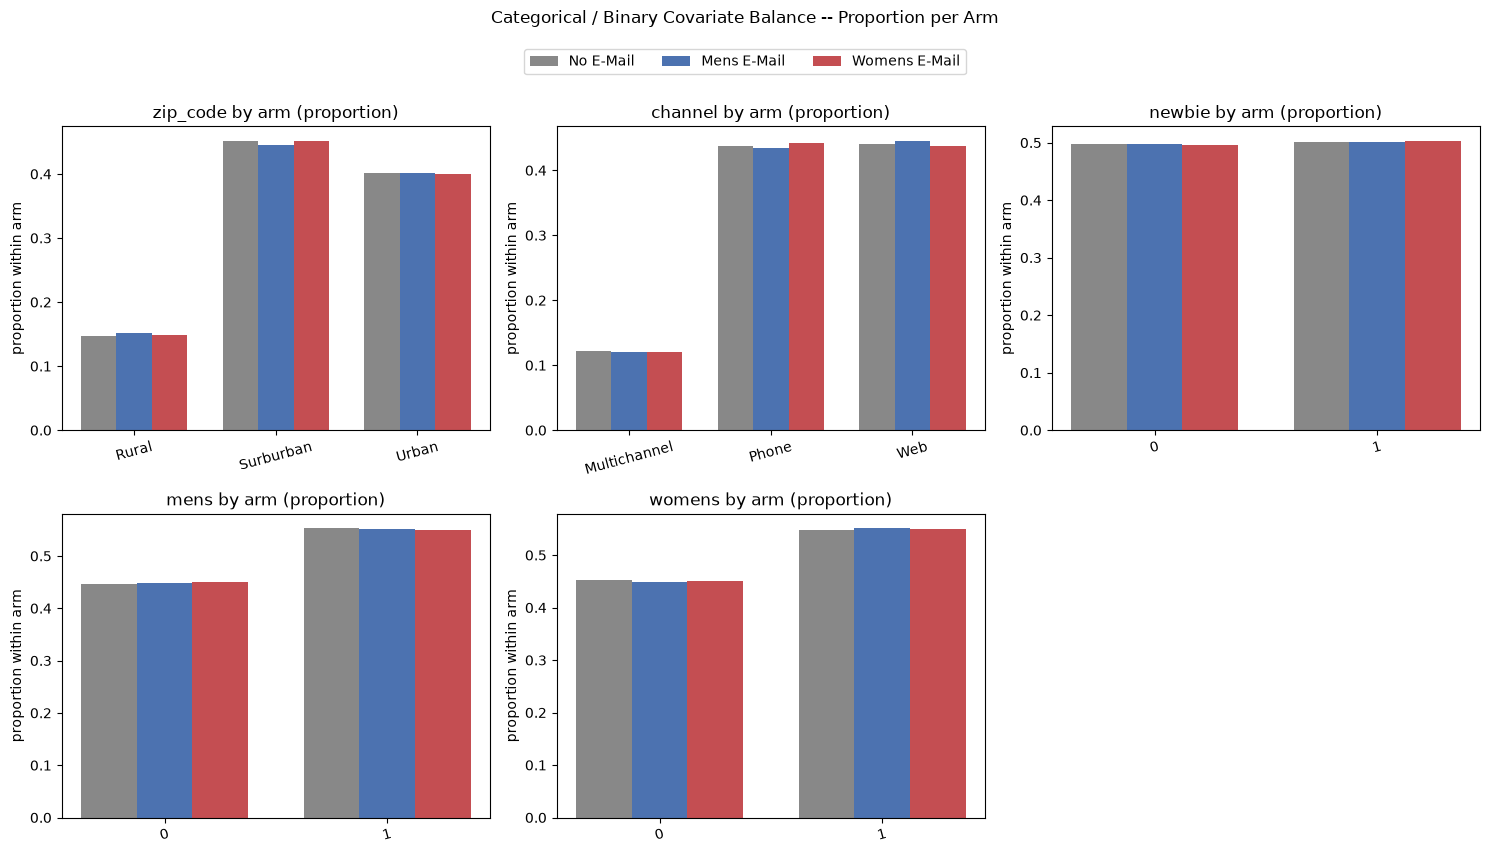

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for ax, feature in zip(axes, CATEGORICAL_FEATURES):
    prop = pd.crosstab(df[TREATMENT_COL], df[feature], normalize="index").reindex(ARM_ORDER)
    prop = prop[sorted(prop.columns, key=str)]
    x = range(len(prop.columns))
    width = 0.25
    for i, arm in enumerate(ARM_ORDER):
        ax.bar([xi + i * width for xi in x], prop.loc[arm], width=width, label=arm, color=COLORS[arm])
    ax.set_xticks([xi + width for xi in x])
    ax.set_xticklabels([str(c) for c in prop.columns], rotation=15)
    ax.set_title(f"{feature} by arm (proportion)")
    ax.set_ylabel("proportion within arm")
for ax in axes[len(CATEGORICAL_FEATURES):]:
    ax.axis("off")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, bbox_to_anchor=(0.5, 1.02))
fig.suptitle("Categorical / Binary Covariate Balance: Proportion per Arm", y=1.06)
fig.tight_layout()
plt.show()